# FreshRAG Temporal-Aware Retrieval Stage Analysis
## Evaluating Temporal Signal Augmentation on Retrieval Performance

This notebook analyzes the **temporal-aware** retrieval stage results across four staleness conditions:
- **Fresh (0%)**: All documents are current
- **Stale-10%**: 10% of answer-bearing docs replaced with outdated versions
- **Stale-30%**: 30% replaced
- **Stale-50%**: 50% replaced

The temporal-aware retrieval augments document embeddings with a freshness signal dimension,
penalizing stale documents and boosting fresh ones in similarity search.

Metrics analyzed:
- Precision@k, Recall@k
- Stale document intrusion rate
- Fresh document displacement
- Retrieval latency
- Breakdown by time-sensitivity and domain

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# ── Style setup ──
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'font.size': 12,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

# Color palette
COLORS = {
    'fresh': '#2ecc71',
    'stale_10': '#f1c40f',
    'stale_30': '#e67e22',
    'stale_50': '#e74c3c',
}
CONDITION_LABELS = {
    'fresh': 'Fresh (0%)',
    'stale_10': 'Stale 10%',
    'stale_30': 'Stale 30%',
    'stale_50': 'Stale 50%',
}
CONDITIONS = ['fresh', 'stale_10', 'stale_30', 'stale_50']
STALENESS_PCTS = [0, 10, 30, 50]

# Output directory for figures
import os
FIGURES_DIR = '../figures_temporal'
os.makedirs(FIGURES_DIR, exist_ok=True)

print('Setup complete.')

Setup complete.


In [2]:
# ── Load data ──
# Reads from the temporal-aware retrieval results
RESULTS_PATH = '../freshrag_experiment/results_temporal/retrieval_temporal_results_aggregated.json'

with open(RESULTS_PATH) as f:
    data = json.load(f)

print(f"Sections: {list(data.keys())}")
print(f"Conditions: {list(data['overall'].keys())}")
print(f"Queries per condition: {data['overall']['fresh']['n']}")
if 'config' in data:
    print(f"Config: alpha={data['config'].get('alpha')}, k={data['config'].get('k')}, model={data['config'].get('model')}")

Sections: ['config', 'overall', 'by_time_sensitivity', 'by_domain', 'by_condition_x_domain']
Conditions: ['fresh', 'stale_10', 'stale_30', 'stale_50']
Queries per condition: 289
Config: alpha=0.2, k=5, model=all-MiniLM-L6-v2


## 1. Overall Performance Degradation
Core finding: how does increasing staleness affect retrieval quality with temporal signal augmentation?

In [3]:
# ── Build overview dataframe ──
overview_rows = []
for cond in CONDITIONS:
    d = data['overall'][cond]
    overview_rows.append({
        'Condition': CONDITION_LABELS[cond],
        'Staleness %': STALENESS_PCTS[CONDITIONS.index(cond)],
        'Precision@5': d['precision_at_k_mean'],
        'Recall@5': d['recall_at_k_mean'],
        'Stale Intrusion Rate': d['stale_intrusion_rate_mean'],
        'Stale Docs in Top-5': d['stale_in_top_k_mean'],
        'Fresh AB Retrieved': d['fresh_answer_bearing_retrieved_mean'],
        'Stale AB Retrieved': d['stale_answer_bearing_retrieved_mean'],
        'Latency (ms)': d['latency_ms_mean'],
        'Avg Similarity': d['avg_similarity_score_mean'],
    })

df_overview = pd.DataFrame(overview_rows)
df_overview.set_index('Condition', inplace=True)
df_overview.style.format({
    'Precision@5': '{:.4f}',
    'Recall@5': '{:.4f}',
    'Stale Intrusion Rate': '{:.4f}',
    'Stale Docs in Top-5': '{:.2f}',
    'Fresh AB Retrieved': '{:.2f}',
    'Stale AB Retrieved': '{:.2f}',
    'Latency (ms)': '{:.2f}',
    'Avg Similarity': '{:.4f}',
}).background_gradient(cmap='RdYlGn_r', subset=['Stale Intrusion Rate', 'Stale Docs in Top-5'])

,Staleness %,Precision@5,Recall@5,Stale Intrusion Rate,Stale Docs in Top-5,Fresh AB Retrieved,Stale AB Retrieved,Latency (ms),Avg Similarity
Condition,,,,,,,,,
Fresh (0%),0,0.2401,0.6006,0.0000,0.00,1.20,0.00,16.92,0.5079
Stale 10%,10,0.2394,0.5988,0.0118,0.06,1.14,0.06,11.80,0.5068
Stale 30%,30,0.2325,0.5902,0.0325,0.16,1.04,0.12,12.32,0.5035
Stale 50%,50,0.2291,0.5815,0.0547,0.27,0.93,0.21,11.85,0.5006


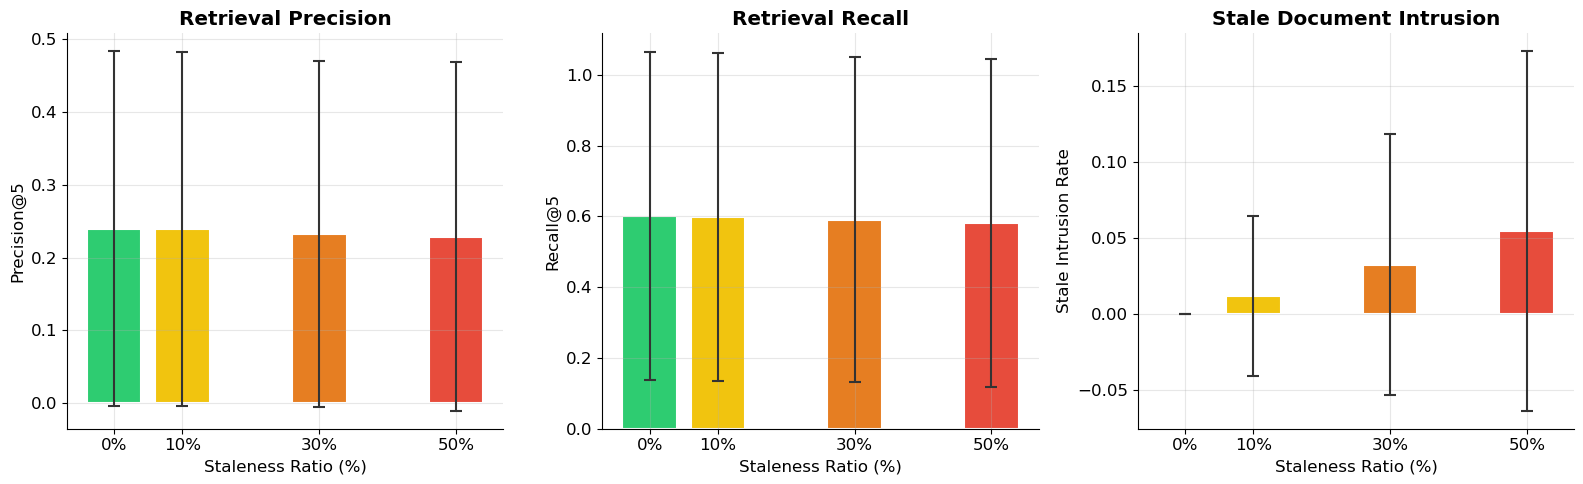

Saved: ../figures_temporal/fig1_retrieval_temporal_degradation.png


In [4]:
# ── Fig 1: Key Metrics Degradation Curves ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = [
    ('precision_at_k_mean', 'precision_at_k_std', 'Precision@5', 'Retrieval Precision'),
    ('recall_at_k_mean', 'recall_at_k_std', 'Recall@5', 'Retrieval Recall'),
    ('stale_intrusion_rate_mean', 'stale_intrusion_rate_std', 'Stale Intrusion Rate', 'Stale Document Intrusion'),
]

for ax, (mean_key, std_key, ylabel, title) in zip(axes, metrics):
    means = [data['overall'][c][mean_key] for c in CONDITIONS]
    stds = [data['overall'][c][std_key] for c in CONDITIONS]
    
    colors = [COLORS[c] for c in CONDITIONS]
    ax.bar(STALENESS_PCTS, means, width=8, color=colors, edgecolor='white', linewidth=1.5)
    ax.errorbar(STALENESS_PCTS, means, yerr=stds, fmt='none', color='#333', capsize=4, capthick=1.5)
    
    ax.set_xlabel('Staleness Ratio (%)')
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    ax.set_xticks(STALENESS_PCTS)
    ax.set_xticklabels(['0%', '10%', '30%', '50%'])

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig1_retrieval_temporal_degradation.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {FIGURES_DIR}/fig1_retrieval_temporal_degradation.png')

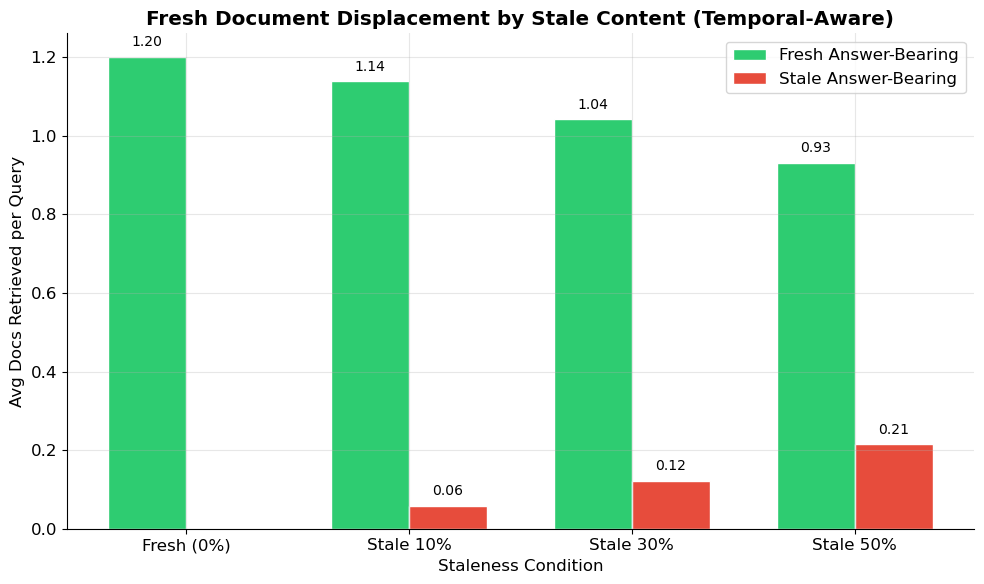

Saved: ../figures_temporal/fig2_temporal_displacement.png


In [5]:
# ── Fig 2: Fresh Document Displacement ──
# Shows how stale docs push fresh answer-bearing docs out of top-k

fig, ax = plt.subplots(figsize=(10, 6))

fresh_ab = [data['overall'][c]['fresh_answer_bearing_retrieved_mean'] for c in CONDITIONS]
stale_ab = [data['overall'][c]['stale_answer_bearing_retrieved_mean'] for c in CONDITIONS]

x = np.arange(len(CONDITIONS))
width = 0.35

bars1 = ax.bar(x - width/2, fresh_ab, width, label='Fresh Answer-Bearing', color='#2ecc71', edgecolor='white')
bars2 = ax.bar(x + width/2, stale_ab, width, label='Stale Answer-Bearing', color='#e74c3c', edgecolor='white')

ax.set_xlabel('Staleness Condition')
ax.set_ylabel('Avg Docs Retrieved per Query')
ax.set_title('Fresh Document Displacement by Stale Content (Temporal-Aware)', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([CONDITION_LABELS[c] for c in CONDITIONS])
ax.legend()

# Add value labels on bars
for bar in bars1:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h + 0.02, f'{h:.2f}', ha='center', va='bottom', fontsize=10)
for bar in bars2:
    h = bar.get_height()
    if h > 0.01:
        ax.text(bar.get_x() + bar.get_width()/2., h + 0.02, f'{h:.2f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig2_temporal_displacement.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {FIGURES_DIR}/fig2_temporal_displacement.png')

## 2. Time-Sensitive vs. Time-Insensitive Comparison
Key hypothesis: Time-sensitive queries degrade more steeply, but time-insensitive queries also show indirect contamination.

In [6]:
# ── Build time-sensitivity dataframe ──
ts_rows = []
for cond in CONDITIONS:
    for ts_label, ts_key in [('Time-Sensitive', 'time_sensitive'), ('Time-Insensitive', 'time_insensitive')]:
        key = f"{cond}__{ts_key}"
        d = data['by_time_sensitivity'].get(key, {})
        if d:
            ts_rows.append({
                'Condition': CONDITION_LABELS[cond],
                'Staleness %': STALENESS_PCTS[CONDITIONS.index(cond)],
                'Query Type': ts_label,
                'Precision@5': d.get('precision_at_k_mean', 0),
                'Recall@5': d.get('recall_at_k_mean', 0),
                'Stale Intrusion': d.get('stale_intrusion_rate_mean', 0),
                'Fresh AB Retrieved': d.get('fresh_answer_bearing_retrieved_mean', 0),
                'Stale AB Retrieved': d.get('stale_answer_bearing_retrieved_mean', 0),
            })

df_ts = pd.DataFrame(ts_rows)
print(df_ts.to_string(index=False, float_format='{:.4f}'.format))

 Condition  Staleness %       Query Type  Precision@5  Recall@5  Stale Intrusion  Fresh AB Retrieved  Stale AB Retrieved
Fresh (0%)            0   Time-Sensitive       0.2360    0.6177           0.0000              1.1799              0.0000
Fresh (0%)            0 Time-Insensitive       0.2440    0.5847           0.0000              1.2200              0.0000
 Stale 10%           10   Time-Sensitive       0.2345    0.6141           0.0245              1.0504              0.1223
 Stale 10%           10 Time-Insensitive       0.2440    0.5847           0.0000              1.2200              0.0000
 Stale 30%           30   Time-Sensitive       0.2187    0.5890           0.0576              0.8417              0.2518
 Stale 30%           30 Time-Insensitive       0.2453    0.5913           0.0093              1.2267              0.0000
 Stale 50%           50   Time-Sensitive       0.2086    0.5674           0.1022              0.5971              0.4460
 Stale 50%           50 Time-Ins

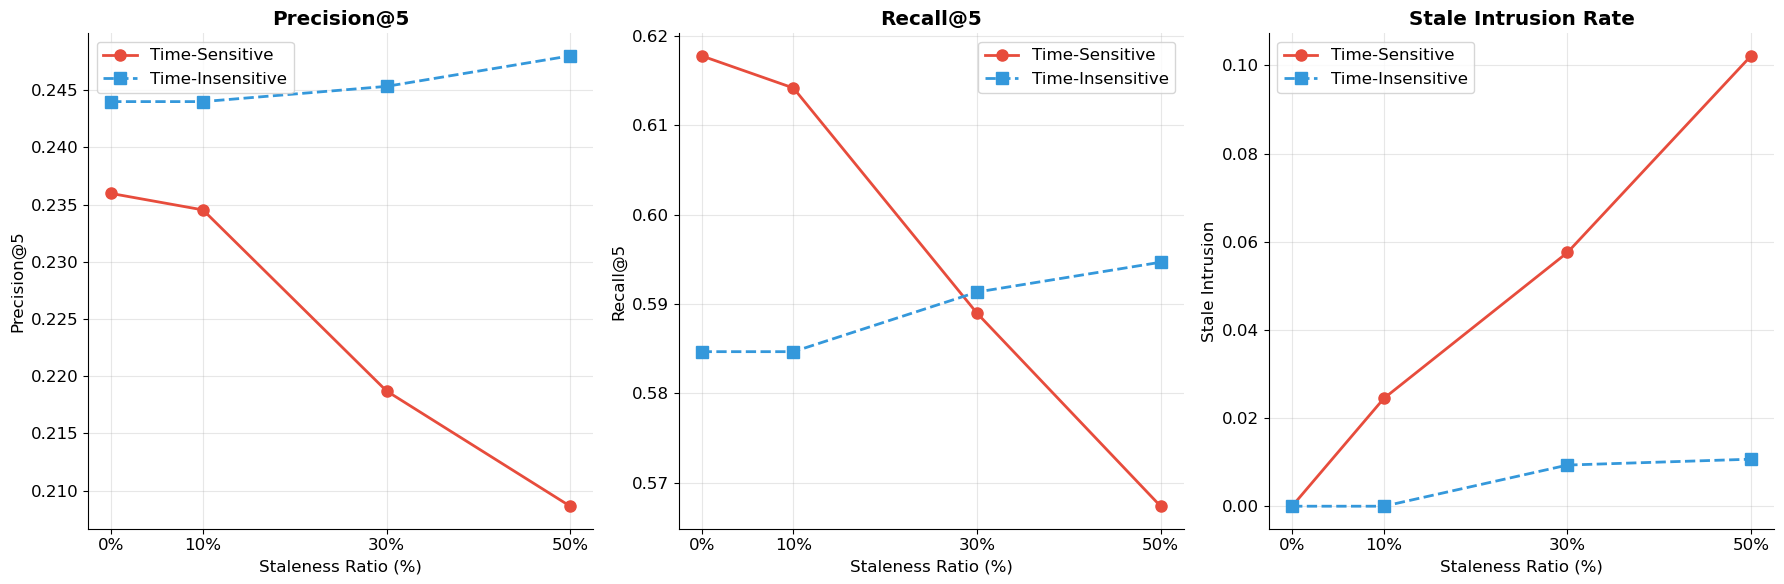

Saved: ../figures_temporal/fig3_temporal_time_sensitivity.png


In [7]:
# ── Fig 3: Side-by-side time-sensitivity comparison ──
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metric_configs = [
    ('Precision@5', 'Precision@5'),
    ('Recall@5', 'Recall@5'),
    ('Stale Intrusion', 'Stale Intrusion Rate'),
]

for ax, (col, title) in zip(axes, metric_configs):
    for qt, style in [('Time-Sensitive', '-o'), ('Time-Insensitive', '--s')]:
        subset = df_ts[df_ts['Query Type'] == qt]
        color = '#e74c3c' if qt == 'Time-Sensitive' else '#3498db'
        ax.plot(subset['Staleness %'], subset[col], style, 
                label=qt, color=color, linewidth=2, markersize=8)
    
    ax.set_xlabel('Staleness Ratio (%)')
    ax.set_ylabel(col)
    ax.set_title(title, fontweight='bold')
    ax.set_xticks(STALENESS_PCTS)
    ax.set_xticklabels(['0%', '10%', '30%', '50%'])
    ax.legend()

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig3_temporal_time_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {FIGURES_DIR}/fig3_temporal_time_sensitivity.png')

In [8]:
# ── Compute degradation delta ──
# How much worse is stale_50 vs fresh for each query type?

print('=== Degradation from Fresh → Stale-50% (Temporal-Aware) ===')
print()

for qt_label, qt_key in [('Time-Sensitive', 'time_sensitive'), ('Time-Insensitive', 'time_insensitive')]:
    fresh_d = data['by_time_sensitivity'].get(f'fresh__{qt_key}', {})
    stale50_d = data['by_time_sensitivity'].get(f'stale_50__{qt_key}', {})
    
    if fresh_d and stale50_d:
        prec_delta = stale50_d.get('precision_at_k_mean', 0) - fresh_d.get('precision_at_k_mean', 0)
        recall_delta = stale50_d.get('recall_at_k_mean', 0) - fresh_d.get('recall_at_k_mean', 0)
        intrusion = stale50_d.get('stale_intrusion_rate_mean', 0)
        fresh_ab_delta = stale50_d.get('fresh_answer_bearing_retrieved_mean', 0) - fresh_d.get('fresh_answer_bearing_retrieved_mean', 0)
        
        print(f'{qt_label}:')
        print(f'  Precision@5 change:     {prec_delta:+.4f} ({prec_delta/max(fresh_d.get("precision_at_k_mean", 1), 0.0001)*100:+.1f}%)')
        print(f'  Recall@5 change:        {recall_delta:+.4f} ({recall_delta/max(fresh_d.get("recall_at_k_mean", 1), 0.0001)*100:+.1f}%)')
        print(f'  Stale intrusion rate:   {intrusion:.4f}')
        print(f'  Fresh AB docs change:   {fresh_ab_delta:+.2f}')
        print()

=== Degradation from Fresh → Stale-50% (Temporal-Aware) ===

Time-Sensitive:
  Precision@5 change:     -0.0273 (-11.6%)
  Recall@5 change:        -0.0504 (-8.2%)
  Stale intrusion rate:   0.1022
  Fresh AB docs change:   -0.58

Time-Insensitive:
  Precision@5 change:     +0.0040 (+1.6%)
  Recall@5 change:        +0.0100 (+1.7%)
  Stale intrusion rate:   0.0107
  Fresh AB docs change:   +0.02



## 3. Domain-Level Analysis
Which enterprise domains are most vulnerable to content staleness with temporal signal augmentation?

In [9]:
# ── Build domain dataframe ──
DOMAINS = ['covidqa', 'cuad', 'expertqa', 'finqa', 'techqa']
DOMAIN_LABELS = {
    'covidqa': 'Healthcare',
    'cuad': 'Legal',
    'expertqa': 'Expert/Cross-domain',
    'finqa': 'Finance',
    'techqa': 'SaaS/IT',
}

domain_rows = []
for cond in CONDITIONS:
    for domain in DOMAINS:
        key = f"{cond}__{domain}"
        d = data['by_domain'].get(key, {})
        if d:
            domain_rows.append({
                'Condition': CONDITION_LABELS[cond],
                'Staleness %': STALENESS_PCTS[CONDITIONS.index(cond)],
                'Domain': DOMAIN_LABELS.get(domain, domain),
                'domain_key': domain,
                'Precision@5': d.get('precision_at_k_mean', 0),
                'Recall@5': d.get('recall_at_k_mean', 0),
                'Stale Intrusion': d.get('stale_intrusion_rate_mean', 0),
                'n': d.get('n', 0),
            })

df_domain = pd.DataFrame(domain_rows)

# Pivot table: Precision by domain x condition
pivot = df_domain.pivot_table(index='Domain', columns='Condition', values='Precision@5')
pivot = pivot[[CONDITION_LABELS[c] for c in CONDITIONS]]
print('Precision@5 by Domain × Condition (Temporal-Aware):')
print(pivot.to_string(float_format='{:.4f}'.format))

Precision@5 by Domain × Condition (Temporal-Aware):
Condition            Fresh (0%)  Stale 10%  Stale 30%  Stale 50%
Domain                                                          
Expert/Cross-domain      0.4379     0.4379     0.4310     0.4310
Finance                  0.1567     0.1533     0.1567     0.1533
Healthcare               0.4414     0.4414     0.4276     0.4207
Legal                    0.0109     0.0109     0.0073     0.0073
SaaS/IT                  0.1448     0.1448     0.1310     0.1241


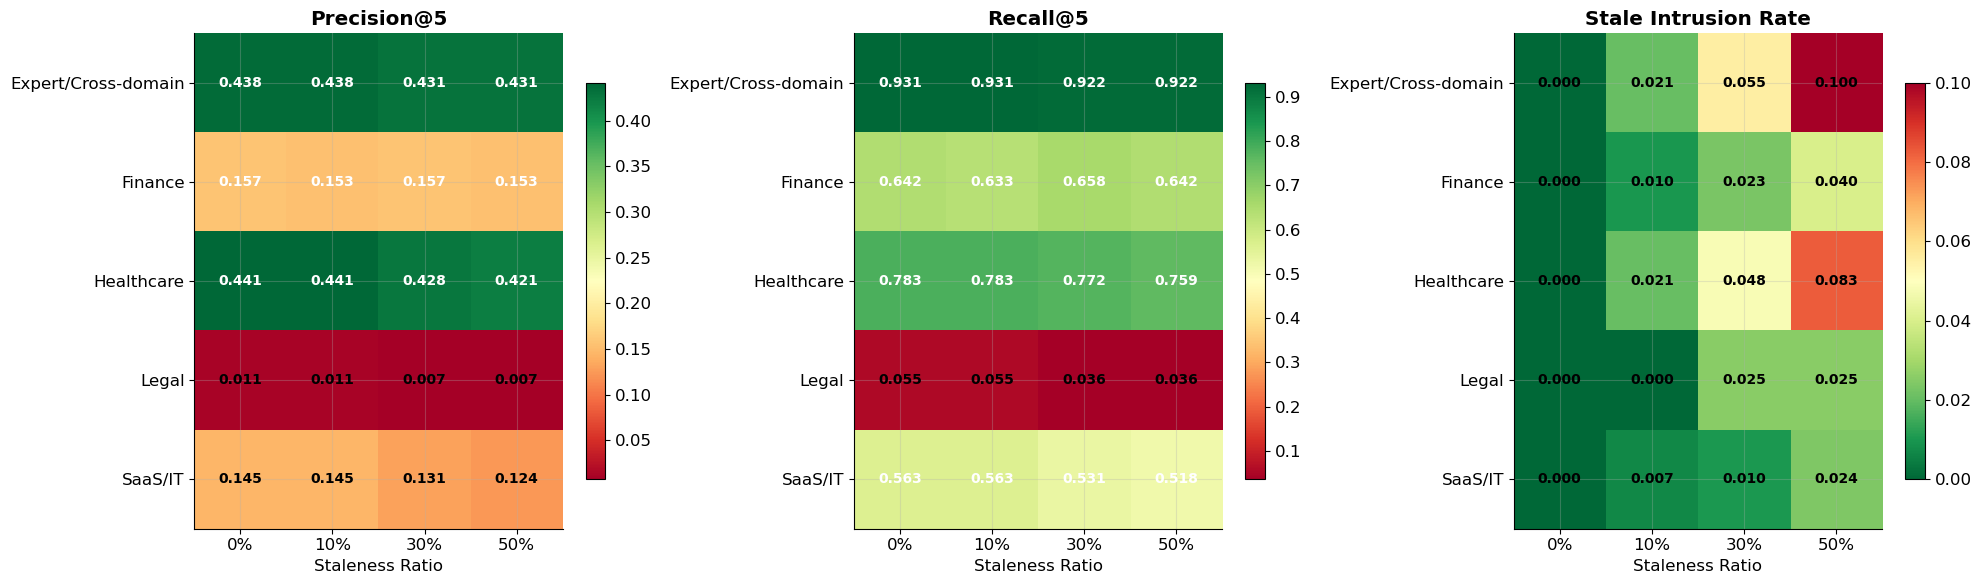

Saved: ../figures_temporal/fig4_temporal_domain_heatmap.png


In [10]:
# ── Fig 4: Domain degradation heatmap ──
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, metric, title in zip(axes, 
    ['Precision@5', 'Recall@5', 'Stale Intrusion'],
    ['Precision@5', 'Recall@5', 'Stale Intrusion Rate']):
    
    pivot = df_domain.pivot_table(index='Domain', columns='Staleness %', values=metric)
    pivot = pivot[[0, 10, 30, 50]]
    
    cmap = 'RdYlGn' if metric != 'Stale Intrusion' else 'RdYlGn_r'
    im = ax.imshow(pivot.values, cmap=cmap, aspect='auto')
    
    ax.set_xticks(range(4))
    ax.set_xticklabels(['0%', '10%', '30%', '50%'])
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_xlabel('Staleness Ratio')
    ax.set_title(title, fontweight='bold')
    
    # Add value annotations
    for i in range(len(pivot.index)):
        for j in range(4):
            val = pivot.values[i, j]
            text_color = 'white' if abs(val) > 0.15 else 'black'
            ax.text(j, i, f'{val:.3f}', ha='center', va='center', 
                    fontsize=10, fontweight='bold', color=text_color)
    
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig4_temporal_domain_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {FIGURES_DIR}/fig4_temporal_domain_heatmap.png')

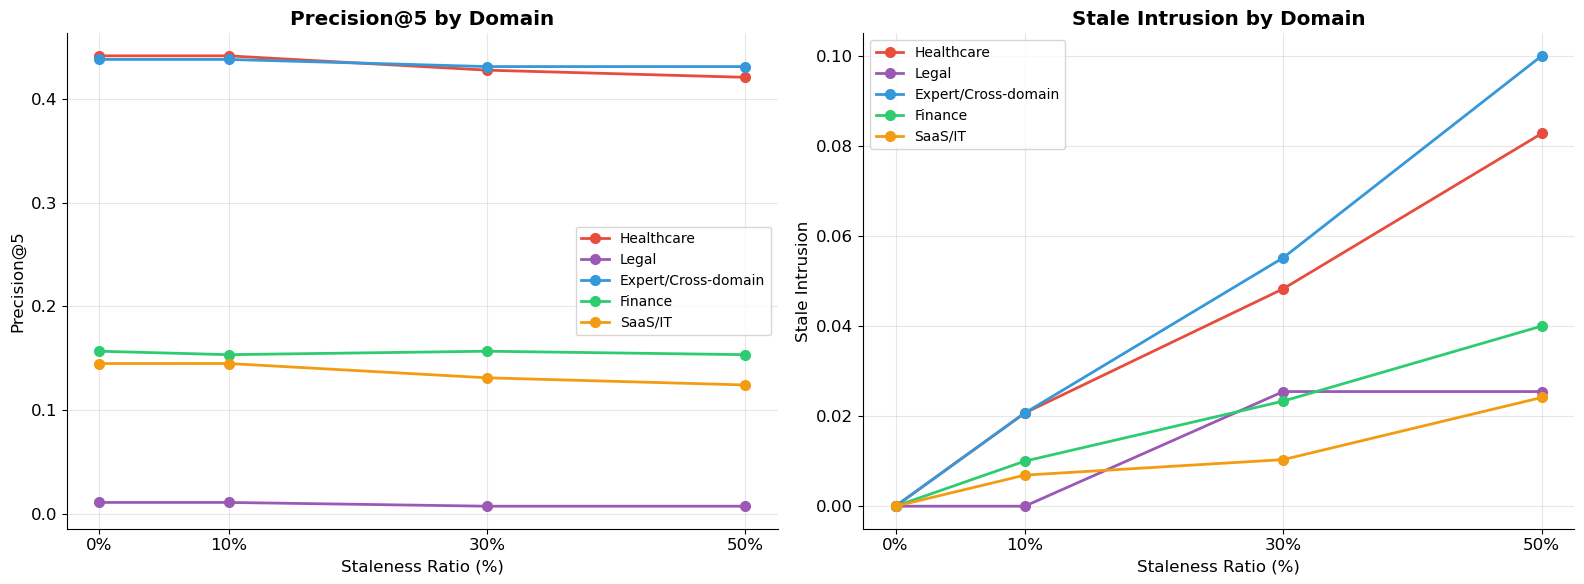

Saved: ../figures_temporal/fig5_temporal_domain_curves.png


In [11]:
# ── Fig 5: Domain-specific degradation curves ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

domain_colors = {
    'Healthcare': '#e74c3c',
    'Legal': '#9b59b6',
    'Expert/Cross-domain': '#3498db',
    'Finance': '#2ecc71',
    'SaaS/IT': '#f39c12',
}

for ax, metric, title in zip(axes, ['Precision@5', 'Stale Intrusion'], ['Precision@5 by Domain', 'Stale Intrusion by Domain']):
    for domain_label in DOMAIN_LABELS.values():
        subset = df_domain[df_domain['Domain'] == domain_label]
        ax.plot(subset['Staleness %'], subset[metric], '-o',
                label=domain_label, color=domain_colors.get(domain_label, '#333'),
                linewidth=2, markersize=7)
    
    ax.set_xlabel('Staleness Ratio (%)')
    ax.set_ylabel(metric)
    ax.set_title(title, fontweight='bold')
    ax.set_xticks(STALENESS_PCTS)
    ax.set_xticklabels(['0%', '10%', '30%', '50%'])
    ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig5_temporal_domain_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {FIGURES_DIR}/fig5_temporal_domain_curves.png')

## 4. Effect of Temporal Signal on Similarity Scores
Does the temporal augmentation successfully differentiate fresh from stale documents in the augmented embedding space?

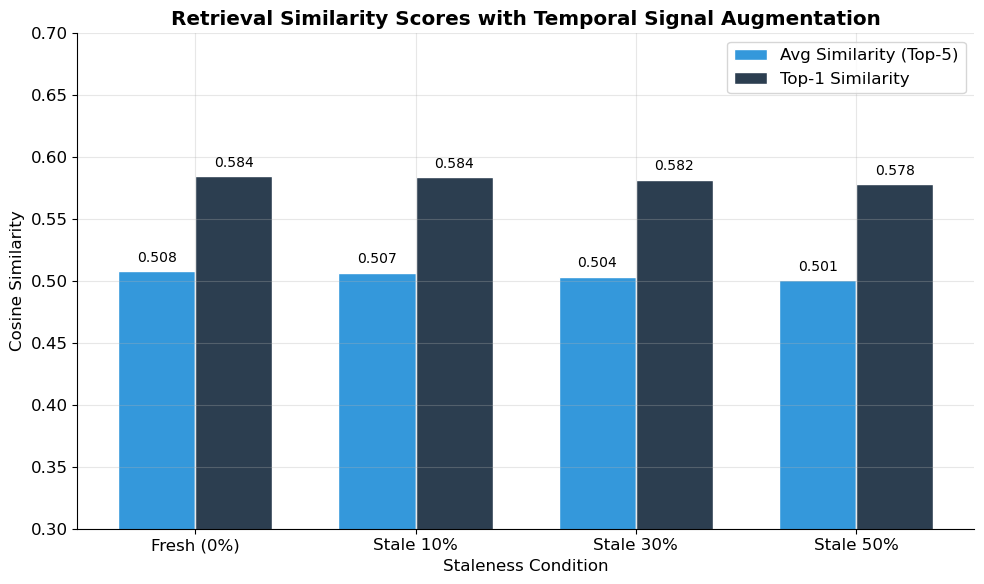


Key finding: Similarity scores changed by -0.0073 from Fresh to Stale-50%
Stale intrusion rate at 50%: 0.0547
→ Compare with baseline retrieval to assess temporal signal effectiveness.


In [12]:
# ── Fig 6: Similarity scores with temporal augmentation ──
fig, ax = plt.subplots(figsize=(10, 6))

avg_sims = [data['overall'][c]['avg_similarity_score_mean'] for c in CONDITIONS]
top_sims = [data['overall'][c]['top_similarity_score_mean'] for c in CONDITIONS]

x = np.arange(len(CONDITIONS))
width = 0.35

bars1 = ax.bar(x - width/2, avg_sims, width, label='Avg Similarity (Top-5)', color='#3498db', edgecolor='white')
bars2 = ax.bar(x + width/2, top_sims, width, label='Top-1 Similarity', color='#2c3e50', edgecolor='white')

ax.set_xlabel('Staleness Condition')
ax.set_ylabel('Cosine Similarity')
ax.set_title('Retrieval Similarity Scores with Temporal Signal Augmentation', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([CONDITION_LABELS[c] for c in CONDITIONS])
ax.legend()
ax.set_ylim(0.3, 0.7)

# Value labels
for bar in bars1:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h + 0.005, f'{h:.3f}', ha='center', va='bottom', fontsize=10)
for bar in bars2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h + 0.005, f'{h:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig6_temporal_similarity.png', dpi=150, bbox_inches='tight')
plt.show()

# Print the key insight
sim_change = avg_sims[-1] - avg_sims[0]
intrusion_change = data['overall']['stale_50']['stale_intrusion_rate_mean']
print(f'\nKey finding: Similarity scores changed by {sim_change:+.4f} from Fresh to Stale-50%')
print(f'Stale intrusion rate at 50%: {intrusion_change:.4f}')
print('\u2192 Compare with baseline retrieval to assess temporal signal effectiveness.')

## 5. Non-linearity Analysis (RQ2)
Is the degradation linear, or does it accelerate at a certain threshold?

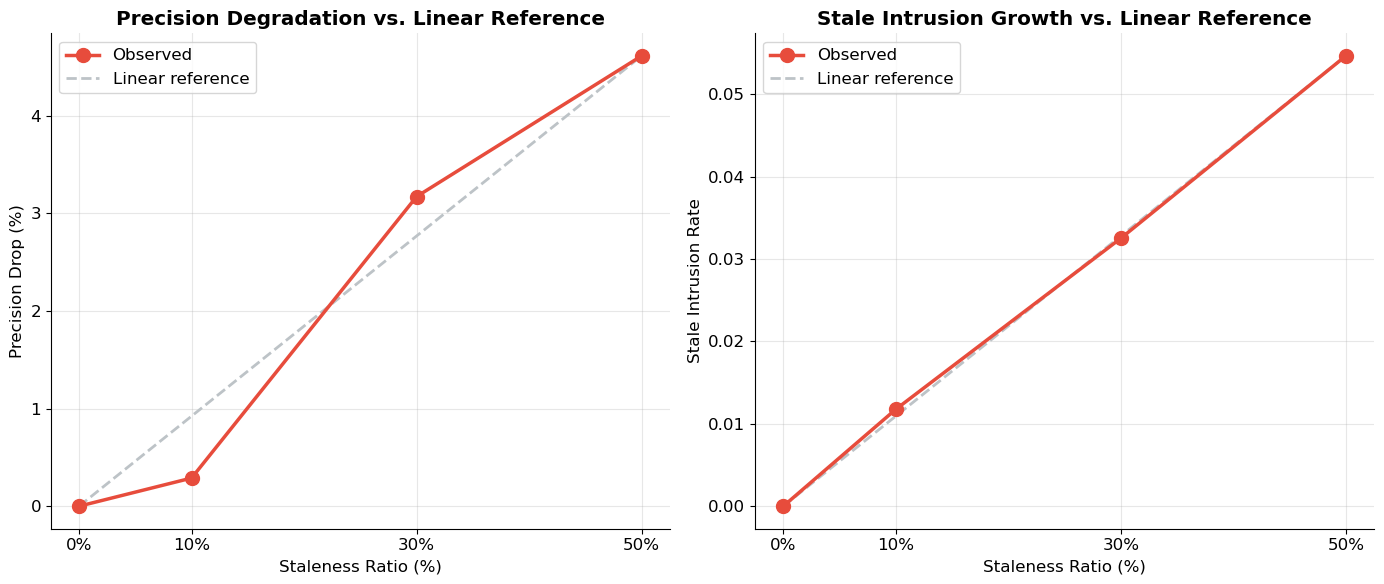

Marginal degradation per 10% staleness increase:
  0% → 10%: Precision Δ=+0.0007/10%, Intrusion Δ=+0.0118/10%
  10% → 30%: Precision Δ=+0.0035/10%, Intrusion Δ=+0.0104/10%
  30% → 50%: Precision Δ=+0.0017/10%, Intrusion Δ=+0.0111/10%


In [13]:
# ── Fig 7: Non-linearity test ──
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Precision degradation
prec_vals = [data['overall'][c]['precision_at_k_mean'] for c in CONDITIONS]
prec_baseline = prec_vals[0]
prec_drops = [(prec_baseline - v) / max(prec_baseline, 0.0001) * 100 for v in prec_vals]

# Stale intrusion growth
intrusion_vals = [data['overall'][c]['stale_intrusion_rate_mean'] for c in CONDITIONS]

# Linear reference line
linear_prec = np.interp(STALENESS_PCTS, [0, 50], [prec_drops[0], prec_drops[-1]])
linear_intr = np.interp(STALENESS_PCTS, [0, 50], [intrusion_vals[0], intrusion_vals[-1]])

ax = axes[0]
ax.plot(STALENESS_PCTS, prec_drops, '-o', color='#e74c3c', linewidth=2.5, markersize=10, label='Observed', zorder=3)
ax.plot(STALENESS_PCTS, linear_prec, '--', color='#bdc3c7', linewidth=2, label='Linear reference')
ax.set_xlabel('Staleness Ratio (%)')
ax.set_ylabel('Precision Drop (%)')
ax.set_title('Precision Degradation vs. Linear Reference', fontweight='bold')
ax.set_xticks(STALENESS_PCTS)
ax.set_xticklabels(['0%', '10%', '30%', '50%'])
ax.legend()

ax = axes[1]
ax.plot(STALENESS_PCTS, intrusion_vals, '-o', color='#e74c3c', linewidth=2.5, markersize=10, label='Observed', zorder=3)
ax.plot(STALENESS_PCTS, linear_intr, '--', color='#bdc3c7', linewidth=2, label='Linear reference')
ax.set_xlabel('Staleness Ratio (%)')
ax.set_ylabel('Stale Intrusion Rate')
ax.set_title('Stale Intrusion Growth vs. Linear Reference', fontweight='bold')
ax.set_xticks(STALENESS_PCTS)
ax.set_xticklabels(['0%', '10%', '30%', '50%'])
ax.legend()

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig7_temporal_nonlinearity.png', dpi=150, bbox_inches='tight')
plt.show()

# Marginal degradation rate
print('Marginal degradation per 10% staleness increase:')
for i in range(1, len(CONDITIONS)):
    delta_pct = STALENESS_PCTS[i] - STALENESS_PCTS[i-1]
    prec_marginal = (prec_vals[i-1] - prec_vals[i]) / delta_pct * 10
    intr_marginal = (intrusion_vals[i] - intrusion_vals[i-1]) / delta_pct * 10
    print(f'  {STALENESS_PCTS[i-1]}% → {STALENESS_PCTS[i]}%: '
          f'Precision Δ={prec_marginal:+.4f}/10%, '
          f'Intrusion Δ={intr_marginal:+.4f}/10%')

## 6. Summary Statistics for Paper/Presentation

In [14]:
# ── Key numbers for the proposal/presentation ──
fresh = data['overall']['fresh']
stale50 = data['overall']['stale_50']

print('=' * 60)
print('KEY FINDINGS — TEMPORAL-AWARE RETRIEVAL STAGE')
print('=' * 60)

prec_drop = (fresh['precision_at_k_mean'] - stale50['precision_at_k_mean']) / fresh['precision_at_k_mean'] * 100
recall_drop = (fresh['recall_at_k_mean'] - stale50['recall_at_k_mean']) / fresh['recall_at_k_mean'] * 100
fresh_ab_drop = (fresh['fresh_answer_bearing_retrieved_mean'] - stale50['fresh_answer_bearing_retrieved_mean']) / fresh['fresh_answer_bearing_retrieved_mean'] * 100

print(f'\n1. PRECISION@5')
print(f'   Fresh:     {fresh["precision_at_k_mean"]:.4f}')
print(f'   Stale-50%: {stale50["precision_at_k_mean"]:.4f}')
print(f'   Drop:      {prec_drop:.1f}%')

print(f'\n2. RECALL@5')
print(f'   Fresh:     {fresh["recall_at_k_mean"]:.4f}')
print(f'   Stale-50%: {stale50["recall_at_k_mean"]:.4f}')
print(f'   Drop:      {recall_drop:.1f}%')

print(f'\n3. STALE INTRUSION')
print(f'   At 10% staleness: {data["overall"]["stale_10"]["stale_intrusion_rate_mean"]:.4f} ({data["overall"]["stale_10"]["stale_in_top_k_mean"]:.2f} docs/query)')
print(f'   At 30% staleness: {data["overall"]["stale_30"]["stale_intrusion_rate_mean"]:.4f} ({data["overall"]["stale_30"]["stale_in_top_k_mean"]:.2f} docs/query)')
print(f'   At 50% staleness: {stale50["stale_intrusion_rate_mean"]:.4f} ({stale50["stale_in_top_k_mean"]:.2f} docs/query)')

print(f'\n4. FRESH DOCUMENT DISPLACEMENT')
print(f'   Fresh AB docs retrieved (Fresh):     {fresh["fresh_answer_bearing_retrieved_mean"]:.2f}')
print(f'   Fresh AB docs retrieved (Stale-50%): {stale50["fresh_answer_bearing_retrieved_mean"]:.2f}')
print(f'   Drop: {fresh_ab_drop:.1f}%')

print(f'\n5. TEMPORAL SIGNAL EFFECT')
print(f'   Avg similarity (Fresh):     {fresh["avg_similarity_score_mean"]:.4f}')
print(f'   Avg similarity (Stale-50%): {stale50["avg_similarity_score_mean"]:.4f}')
print(f'   Change: {(stale50["avg_similarity_score_mean"] - fresh["avg_similarity_score_mean"]):.4f}')
if 'config' in data:
    print(f'   Alpha used: {data["config"].get("alpha", "N/A")}')

# Most affected domain
print(f'\n6. MOST AFFECTED DOMAIN')
max_intrusion = 0
max_domain = ''
for domain in DOMAINS:
    key = f'stale_50__{domain}'
    d = data['by_domain'].get(key, {})
    if d and d.get('stale_intrusion_rate_mean', 0) > max_intrusion:
        max_intrusion = d['stale_intrusion_rate_mean']
        max_domain = DOMAIN_LABELS[domain]
print(f'   {max_domain}: {max_intrusion:.4f} stale intrusion rate at 50% staleness')

KEY FINDINGS — TEMPORAL-AWARE RETRIEVAL STAGE

1. PRECISION@5
   Fresh:     0.2401
   Stale-50%: 0.2291
   Drop:      4.6%

2. RECALL@5
   Fresh:     0.6006
   Stale-50%: 0.5815
   Drop:      3.2%

3. STALE INTRUSION
   At 10% staleness: 0.0118 (0.06 docs/query)
   At 30% staleness: 0.0325 (0.16 docs/query)
   At 50% staleness: 0.0547 (0.27 docs/query)

4. FRESH DOCUMENT DISPLACEMENT
   Fresh AB docs retrieved (Fresh):     1.20
   Fresh AB docs retrieved (Stale-50%): 0.93
   Drop: 22.5%

5. TEMPORAL SIGNAL EFFECT
   Avg similarity (Fresh):     0.5079
   Avg similarity (Stale-50%): 0.5006
   Change: -0.0073
   Alpha used: 0.2

6. MOST AFFECTED DOMAIN
   Expert/Cross-domain: 0.1000 stale intrusion rate at 50% staleness


In [15]:
# ── Export summary table for presentation ──
os.makedirs('../results', exist_ok=True)
summary_df = df_overview[['Staleness %', 'Precision@5', 'Recall@5', 
                           'Stale Intrusion Rate', 'Fresh AB Retrieved', 
                           'Stale AB Retrieved']].copy()
summary_df.to_csv('../results/retrieval_temporal_summary_table.csv')
print('Exported: results/retrieval_temporal_summary_table.csv')
print()
print(summary_df.to_string(float_format='{:.4f}'.format))

Exported: results/retrieval_temporal_summary_table.csv

            Staleness %  Precision@5  Recall@5  Stale Intrusion Rate  Fresh AB Retrieved  Stale AB Retrieved
Condition                                                                                                   
Fresh (0%)            0       0.2401    0.6006                0.0000              1.2007              0.0000
Stale 10%            10       0.2394    0.5988                0.0118              1.1384              0.0588
Stale 30%            30       0.2325    0.5902                0.0325              1.0415              0.1211
Stale 50%            50       0.2291    0.5815                0.0547              0.9308              0.2145
